In [3]:
%pip install langchain-groq langchain-huggingface langchain-text-splitters sentence-transformers

  Using cached langchain_huggingface-1.2.2-py3-none-any.whl (31 kB)
  Using cached sentence_transformers-5.6.0-py3-none-any.whl (596 kB)
  Using cached huggingface_hub-1.21.0-py3-none-any.whl (721 kB)
  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
  Using cached torch-2.12.1-cp310-cp310-manylinux_2_28_x86_64.whl (532.1 MB)
  Using cached transformers-5.12.1-py3-none-any.whl (11.2 MB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Using cached filelock-3.29.4-py3-none-any.whl (42 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.5 MB)
  Using cached typer-0.25.1-py3-none-any.whl (58 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl (203 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any

In [5]:
%pip install langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [7]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [8]:
load_dotenv()

True

In [9]:
llm = ChatGroq(model='openai/gpt-oss-120b')

In [11]:
%pip install pypdf

  Using cached pypdf-6.14.2-py3-none-any.whl (349 kB)
Note: you may need to restart the kernel to use updated packages.


In [12]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [13]:
len(docs)

392

In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [15]:
len(chunks)

973

In [17]:
%pip install faiss-cpu

  Using cached faiss_cpu-1.14.3-cp310-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (18.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [18]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8403.95it/s]


In [19]:
vector_store

In [20]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [21]:
retriever.invoke('What is a Decision Tree')

[Document(id='98530935-b874-4a77-bbce-d248d6a72cbe', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': 'intro-to-ml.pdf', 'total_pages': 392, 'page': 84, 'page_label': '71'}, page_content='class consisting of 75 data points. We will refer to this dataset as two_moons.\nLearning a decision tree means learning the sequence of if/else questions that gets us\nto the true answer most quickly. In the machine learning setting, these questions are\ncalled tests (not to be confused with the test set, which is the data we use to test to see\nhow generalizable our model is). Usually data does not come in the form of binary\nyes/no features as in t

In [22]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [23]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [24]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [25]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [26]:
tool_node = ToolNode(tools)

In [27]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

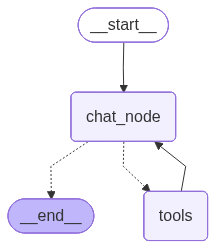

In [28]:
chatbot

In [29]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [30]:
print(result['messages'][-1].content)

**How to Choose the “Ideal” *K* for a k‑Nearest‑Neighbors (KNN) Model  
(Using the material from *Introduction to Machine Learning with Python*)**

---

### 1. Why *K* matters  

| *K* value | What the model does | Typical effect on performance |
|----------|--------------------|------------------------------|
| **K = 1** (or a very small *K*) | The prediction is taken from the single closest training point. | **Low bias, high variance** – the model can fit the training data perfectly (often 100 % training accuracy) but will usually mis‑classify noisy or out‑of‑sample points. |
| **Large *K*** (e.g., *K* ≈ N/2) | The prediction is the majority vote of many neighbours, essentially a smoothed version of the training distribution. | **High bias, low variance** – the model may under‑fit (low training accuracy) and also perform poorly on new data because it “averages away” useful structure. |
| **Intermediate *K*** | A compromise between the two extremes. | Often gives the **best generalisa